In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from ridge_model import fit_ridge, predict_ridge
# On importe aussi OLS pour pouvoir comparer les deux !
from ols_model import fit_ols, predict_ols

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
rng = np.random.default_rng(seed=42)
n_samples = 60

# x1 et x2 sont deux facteurs financiers presque identiques (ex: deux indices corrélés)
x1 = rng.standard_normal((n_samples, 1))
x2 = x1 + rng.standard_normal((n_samples, 1)) * 0.005 # Très forte colinéarité

X = np.hstack((x1, x2))
true_beta = np.array([[4.0], [2.5]]) # Les vrais poids de notre modèle

# Génération de Y avec beaucoup de bruit de marché
Y = 5.0 + X @ true_beta + rng.standard_normal((n_samples, 1)) * 1.5

In [4]:
# Modèle OLS classique
beta_ols = fit_ols(X, Y, fit_intercept=True)

# Modèle Ridge avec une pénalité saine (lam = 15.0)
beta_ridge = fit_ridge(X, Y, lam=15.0, fit_intercept=True)

print("--- COMPARAISON DES COEFFICIENTS (Intercept, Beta_1, Beta_2) ---")
print("Vrais Coefficients théoriques :      [5.0,  4.0,  2.5]")
print(f"Coefficients trouvés par OLS :      {beta_ols.flatten().round(2)}")
print(f"Coefficients trouvés par Ridge :    {beta_ridge.flatten().round(2)}")

--- COMPARAISON DES COEFFICIENTS (Intercept, Beta_1, Beta_2) ---
Vrais Coefficients théoriques :      [5.0,  4.0,  2.5]
Coefficients trouvés par OLS :      [  4.95 -18.74  25.26]
Coefficients trouvés par Ridge :    [5.  2.7 2.7]


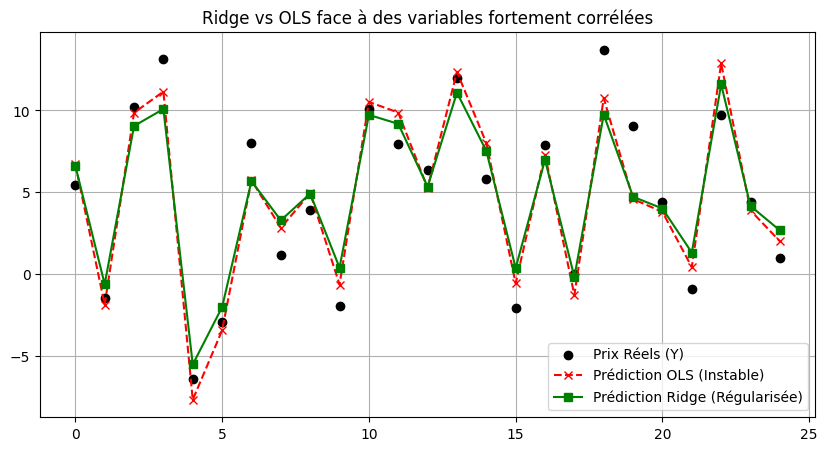

In [5]:
Y_pred_ols = predict_ols(X, beta_ols, fit_intercept=True)
Y_pred_ridge = predict_ridge(X, beta_ridge, fit_intercept=True)

plt.figure(figsize=(10, 5))
plt.plot(Y[:25], label="Prix Réels (Y)", marker='o', color='black', linestyle='none')
plt.plot(Y_pred_ols[:25], label="Prédiction OLS (Instable)", marker='x', color='red', linestyle='--')
plt.plot(Y_pred_ridge[:25], label="Prédiction Ridge (Régularisée)", marker='s', color='green', linestyle='-')

plt.title("Ridge vs OLS face à des variables fortement corrélées")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
"""
A retenir
""" 

# 1. Pourquoi utiliser Ridge plutôt qu'OLS en Finance ?
# --> Le problème de la multi-colinéarité :
# --> Sur les marchés, de nombreux facteurs explicatifs sont fortement corrélés entre eux 
# ex : les rendements de deux indices du même secteur, ou différentes maturités de taux d'intérêt). 
# --> Face à des variables colinéaires, la matrice X^T*X de l'OLS devient quasi-singulière, ce qui fait exploser la variance des coefficients beta. 
# --> Le modèle devient instable et hypersensible au bruit de marché.

# La solution Ridge :
# --> La pénalité L2 force artificiellement la matrice à être bien conditionnée (inversible de manière stable). 
# --> Les coefficients beta sont contraints (shrinkage), ce qui réduit drastiquement la variance des prédictions au prix d'un biais minime.


# 2. Pourquoi ne pénalise-t-on pas l'intercept (I[0, 0] = 0) ?
# --> Principe de régularisation : L'intercept (beta_0) représente la valeur centrale ou moyenne de la cible Y lorsque toutes les variables explicatives sont nulles. 
# --> Pénaliser beta_0 reviendrait à forcer la moyenne de nos prédictions à se rapprocher de zéro, ce qui n'a pas de sens économique.

# Mise en œuvre :
# --> Dans le code, on s'assure que l'élément top-gauche de notre matrice identité de pénalisation vaut explicitement `0` pour laisser l'intercept s'ajuster librement.